In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import figure
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy import linalg
%matplotlib inline

def show_gradient_descent(A, b):
    A = np.asarray(A,dtype=float)
    b = np.asarray(b,dtype=float).reshape(-1)
    x = np.array([-2.0, 2.0])   # initial condition
    alpha = 0.02
    max_iter = 1000
    f = float(np.linalg.norm(A @ x - b)**2)
    for k in range(max_iter):
        print(f"{k}\t({float(x[0]):.4f}, {float(x[1]):.4f})\t{f:.8f}")
        x_prev = x.copy()
        grad = 2 * (A.T @ A @ x - A.T @ b)
        x = x - alpha * grad
        f = float(np.linalg.norm(A @ x - b)**2)
        if np.linalg.norm(x - x_prev) <= 1e-8:
            break


In [2]:
def draw_gradient_descent(A, b):
  xx, yy = np.meshgrid(np.arange(-2,2.1,0.1), np.arange(-2,2.1,0.1))
  F1 = A[0][0]*xx + A[0][1]*yy - b[0];
  F2 = A[1][0]*xx + A[1][1]*yy - b[1];
  zz = F1*F1 + F2*F2;
  plt3d = plt.figure().add_subplot(projection='3d')
  plt3d.plot_surface(xx, yy, zz, alpha=0.7, cmap=cm.coolwarm)
  ax = plt.gca()
  x = np.array([-2.0, 2.0],dtype=float)
  alpha = 0.02
  max_iter = 1000
  A = np.asarray(A,dtype=float)
  b = np.asarray(b,dtype=float).reshape(-1)
  f = float(np.linalg.norm(A @ x - b)**2)
  for k in range(max_iter):
      ax.scatter(x[0], x[1],f, c='r')
      x_prev = x.copy()
      grad = 2 * (A.T @ A @ x - A.T @ b)
      x = x - alpha * grad
      f = float(np.linalg.norm(A @ x - b)**2)
      if np.linalg.norm(x - x_prev) <= 1e-8:
          break
  x1 = np.linspace(-2.0, 2.0, 100)
  x2 = ((A.T @ b)[0] - (A.T @ A)[0,0] * x1) / (A.T @ A)[0,1]
  z = np.zeros_like(x1)
  ax.plot(x1, x2, z, c='b', linewidth=2)
  from matplotlib.ticker import MultipleLocator
  ax.xaxis.set_major_locator(MultipleLocator(0.5))
  ax.yaxis.set_major_locator(MultipleLocator(0.5))
  ax.view_init(elev=35, azim=255)
  plt.show()

0	(-2.0000, 2.0000)	113.00000000
1	(-1.4000, 0.8000)	41.00000000
2	(-1.0400, 0.0800)	15.08000000
3	(-0.8240, -0.3520)	5.74880000
4	(-0.6944, -0.6112)	2.38956800
5	(-0.6166, -0.7667)	1.18024448
6	(-0.5700, -0.8600)	0.74488801
7	(-0.5420, -0.9160)	0.58815968
8	(-0.5252, -0.9496)	0.53173749
9	(-0.5151, -0.9698)	0.51142550
10	(-0.5091, -0.9819)	0.50411318
11	(-0.5054, -0.9891)	0.50148074
12	(-0.5033, -0.9935)	0.50053307
13	(-0.5020, -0.9961)	0.50019190
14	(-0.5012, -0.9976)	0.50006909
15	(-0.5007, -0.9986)	0.50002487
16	(-0.5004, -0.9992)	0.50000895
17	(-0.5003, -0.9995)	0.50000322
18	(-0.5002, -0.9997)	0.50000116
19	(-0.5001, -0.9998)	0.50000042
20	(-0.5001, -0.9999)	0.50000015
21	(-0.5000, -0.9999)	0.50000005
22	(-0.5000, -1.0000)	0.50000002
23	(-0.5000, -1.0000)	0.50000001
24	(-0.5000, -1.0000)	0.50000000
25	(-0.5000, -1.0000)	0.50000000
26	(-0.5000, -1.0000)	0.50000000
27	(-0.5000, -1.0000)	0.50000000
28	(-0.5000, -1.0000)	0.50000000
29	(-0.5000, -1.0000)	0.50000000
30	(-0.5000, -1.000

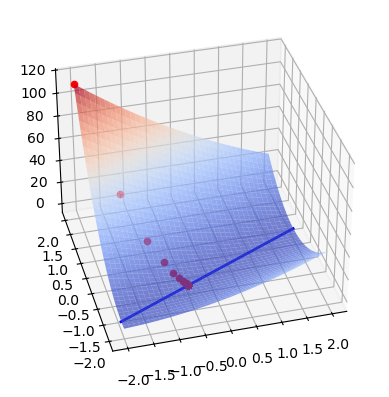

In [3]:
if __name__ == '__main__':
  b = np.array([[1], [2]])
  A = np.array([[1, -2], [1, -2]])
  show_gradient_descent(A, b)
  draw_gradient_descent(A, b)

In [ ]:
# Try different learning rates of alpha. How to adjust the learning rate for faster speed of convergence? (4%)
# 如何調整 alpha 使得所需迴圈次數愈少愈好(即較快達到收斂)？
alpha小，更新步數短，收斂慢，alpha變大，收斂會變快。

In [ ]:
# Try different initial points of x. Do different initial points give rise to different to optimal solutions? (4%)
# 不同初始點 x 會使演算法找到不同最佳解嗎?
有可能，因為最佳解不是唯一一點，而是一整條藍線。
不同的初始點做梯度下降，最後可能收斂到這條最佳解線上的不同位置，所以可能找到不同的optimal solutions，但它們都在最佳解集合中(藍線上)。

In [ ]:
# Does the minimum vary with the values of the initial point? (4%)
# 不同初始點 x 會使演算法找到不同最小值嗎?
不會，不同初始點可能收斂到不同的最佳解點，但這些點都是同一個最小值。

In [ ]:
# Is the minimum a local minimum or a global minimum? (4%)
因為目標函數是convex function，所以只要是local minimum，就一定是global minimum。